# 08 — PaySim raw EDA (5-step)

A disciplined Exploratory Data Analysis of the **raw PaySim source** ([`ealaxi/paysim1`](https://www.kaggle.com/datasets/ealaxi/paysim1)) — the 11 original columns, before any feature engineering. It follows the standard 5-step EDA flow: (1) understand, (2) clean/quality-assess, (3) univariate, (4) bi/multivariate, (5) insights + feature-engineering ideas.

It reads the frozen CSV snapshot through `src/` (`connect_paysim`, the same DuckDB approach as notebook 01) and **never mutates the source** — cleaning here is *assessment* (the snapshot is immutable evidence). Plots/correlations use a deterministic reservoir sample.

> **Leakage note (project hard-rule #6).** The four balance columns (`oldbalanceOrg`, `newbalanceOrig`, `oldbalanceDest`, `newbalanceDest`), `isFraud`, and `isFlaggedFraud` are examined here **only to understand the data and demonstrate why they leak** — they are FORBIDDEN as model inputs. This notebook explains the *why* behind that rule; it does not turn them into features.

Review-only / output-free in git (AGENTS §13): calls into `src/`, read-only, clear before commit.

In [37]:
from pathlib import Path

import pandas as pd
from IPython.display import Markdown, display

from pit_fintech.data.paysim import (
    BALANCE_COLUMNS,
    DATASET_URL,
    EXPECTED_COLUMNS,
    LABEL_COLUMNS,
    POLICY_OUTPUT_COLUMNS,
    REQUEST_TIME_COLUMNS,
    connect_paysim,
    find_paysim_csv,
    resolve_project_root,
    setup_instructions,
    validate_paysim_csv,
)
from pit_fintech.features.paysim_specs import PAYSIM_FORBIDDEN_MODEL_INPUTS

PROJECT_ROOT = resolve_project_root(Path.cwd())
paysim_csv = find_paysim_csv(PROJECT_ROOT)
DATA_AVAILABLE = paysim_csv is not None

SAMPLE_ROWS = 200_000  # deterministic reservoir sample for plots / scatter / correlation

connection = None
if DATA_AVAILABLE:
    validate_paysim_csv(paysim_csv)
    connection = connect_paysim(paysim_csv)  # lazy DuckDB view `paysim` over the CSV
    print({"dataset": DATASET_URL, "path": str(paysim_csv), "columns": len(EXPECTED_COLUMNS)})
else:
    display(Markdown("```text\n" + setup_instructions(PROJECT_ROOT) + "\n```"))


def q(sql: str):
    """Run SQL against the raw PaySim view (DuckDB over the CSV); returns a DataFrame."""
    if connection is None:
        print("Query skipped: PaySim CSV is unavailable.")
        return None
    return connection.execute(sql).df()


def sample_df(columns: list[str], rows: int = SAMPLE_ROWS):
    """Deterministic reservoir sample of selected columns for plotting."""
    if connection is None:
        return None
    cols = ", ".join(columns)
    return connection.execute(
        f"SELECT {cols} FROM paysim USING SAMPLE reservoir({int(rows)} ROWS) REPEATABLE (42)"
    ).df()

{'dataset': 'https://www.kaggle.com/datasets/ealaxi/paysim1', 'path': 'C:\\workspace\\pit-fintech\\data\\raw\\PS_20174392719_1491204439457_log.csv', 'columns': 11}


### Plotting helpers
Small matplotlib wrappers with a graceful fallback: if matplotlib is not installed the notebook still runs and shows the underlying numbers instead of a figure.

In [38]:
NUMERIC_COLUMNS = ["amount", *BALANCE_COLUMNS, "step"]
CORRELATION_COLUMNS = [
    "amount",
    *BALANCE_COLUMNS,
    "step",
    *LABEL_COLUMNS,
    *POLICY_OUTPUT_COLUMNS,
]

try:
    import matplotlib.pyplot as plt

    HAS_MPL = True
except ImportError:
    HAS_MPL = False
    print(
        "matplotlib not installed; plots fall back to numeric tables. "
        "Run `.\\make.ps1 setup` to enable figures."
    )


def heatmap(corr, title):
    if not HAS_MPL:
        print(f"[{title}] matplotlib unavailable — numeric matrix below.")
        display(corr.round(2))
        return
    values = corr.values
    fig, ax = plt.subplots(figsize=(8.5, 7.5))
    image = ax.imshow(values, cmap="coolwarm", vmin=-1.0, vmax=1.0)
    ax.set_xticks(range(len(corr.columns)), labels=list(corr.columns), rotation=90, fontsize=8)
    ax.set_yticks(range(len(corr.index)), labels=list(corr.index), fontsize=8)
    for i in range(values.shape[0]):
        for j in range(values.shape[1]):
            ax.text(
                j,
                i,
                f"{values[i, j]:.2f}",
                ha="center",
                va="center",
                fontsize=7,
                color="white" if abs(values[i, j]) > 0.6 else "black",
            )
    ax.set_title(title)
    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
    fig.tight_layout()
    plt.show()


def barh(labels, values, title, xlabel):
    if not HAS_MPL:
        print(f"[{title}]")
        display(pd.DataFrame({"label": labels, xlabel: values}))
        return
    fig, ax = plt.subplots(figsize=(7.5, 0.5 * len(labels) + 1.5))
    ax.barh(range(len(labels)), values, color="#3b6fb0")
    ax.set_yticks(range(len(labels)), labels=labels)
    ax.invert_yaxis()
    ax.set_xlabel(xlabel)
    ax.set_title(title)
    fig.tight_layout()
    plt.show()


def hist(values, title, bins=60, logy=True):
    if not HAS_MPL:
        print(f"[{title}] n={len(values):,}")
        return
    fig, ax = plt.subplots(figsize=(7.5, 4.0))
    ax.hist(values, bins=bins, color="#3b6fb0")
    if logy:
        ax.set_yscale("log")
    ax.set_title(title)
    fig.tight_layout()
    plt.show()


def boxplot(groups, title, ylabel, log=True):
    if not HAS_MPL:
        print(f"[{title}]")
        display(pd.DataFrame({k: pd.Series(v).describe() for k, v in groups.items()}))
        return
    fig, ax = plt.subplots(figsize=(7.5, 4.5))
    ax.boxplot(list(groups.values()), tick_labels=list(groups.keys()), showfliers=False)
    if log:
        ax.set_yscale("symlog")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=30)
    fig.tight_layout()
    plt.show()


def scatter(x, y, hue, title, xlabel, ylabel):
    if not HAS_MPL:
        print(f"[{title}] n={len(x):,}")
        return
    fig, ax = plt.subplots(figsize=(6.5, 6.0))
    ax.scatter(x, y, c=hue, cmap="coolwarm", s=4, alpha=0.4)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    fig.tight_layout()
    plt.show()

## Step 1 · Data understanding
Size, dtypes, a first look, and what each column *means* — including which are forbidden as model inputs and why (label / policy output / post-outcome balance).

In [39]:
if connection is not None:
    shape = q(
        "SELECT count(*) AS rows, " + str(len(EXPECTED_COLUMNS)) + " AS source_columns FROM paysim"
    )
    display(shape)
    display(q("DESCRIBE paysim"))
else:
    print("Skipped: PaySim CSV unavailable.")

,rows,source_columns
0,6362620,11


,column_name,column_type,null,key,default,extra
0,source_row_number,BIGINT,YES,None,None,None
1,step,BIGINT,YES,None,None,None
2,knowledge_step,BIGINT,YES,None,None,None
3,type,VARCHAR,YES,None,None,None
4,amount,DOUBLE,YES,None,None,None
5,nameOrig,VARCHAR,YES,None,None,None
6,oldbalanceOrg,DOUBLE,YES,None,None,None
7,newbalanceOrig,DOUBLE,YES,None,None,None
8,nameDest,VARCHAR,YES,None,None,None
9,oldbalanceDest,DOUBLE,YES,None,None,None


### 📖 Cách đọc
- Bảng đầu: `rows` = tổng số giao dịch, `source_columns` = số cột gốc (11).
- `DESCRIBE`: mỗi dòng một cột và **kiểu dữ liệu** DuckDB — `BIGINT` = số nguyên (step), `DOUBLE` = số thực (amount, balance), `VARCHAR` = chuỗi (type, tên tài khoản). Kiểm tra kiểu có hợp lý với ý nghĩa cột không.

<!--read-guide-->

In [40]:
def _role(column: str) -> str:
    if column in LABEL_COLUMNS:
        return "label (target) — FORBIDDEN input"
    if column in POLICY_OUTPUT_COLUMNS:
        return "rule-engine output — FORBIDDEN input"
    if column in BALANCE_COLUMNS:
        return "post-outcome balance — FORBIDDEN input (leakage)"
    if column in REQUEST_TIME_COLUMNS:
        return "request-time (known before decision)"
    return "other"


dictionary = pd.DataFrame(
    {"column": EXPECTED_COLUMNS, "role": [_role(c) for c in EXPECTED_COLUMNS]}
)
dictionary["forbidden_as_feature"] = dictionary["column"].isin(PAYSIM_FORBIDDEN_MODEL_INPUTS)
display(dictionary)

,column,role,forbidden_as_feature
0,step,request-time (known before decision),False
1,type,request-time (known before decision),False
2,amount,request-time (known before decision),False
3,nameOrig,request-time (known before decision),False
4,oldbalanceOrg,post-outcome balance — FORBIDDEN input (leakage),True
5,newbalanceOrig,post-outcome balance — FORBIDDEN input (leakage),True
6,nameDest,request-time (known before decision),False
7,oldbalanceDest,post-outcome balance — FORBIDDEN input (leakage),True
8,newbalanceDest,post-outcome balance — FORBIDDEN input (leakage),True
9,isFraud,label (target) — FORBIDDEN input,True


### 📖 Cách đọc
Bảng "từ điển cột": `role` cho biết vai trò, `forbidden_as_feature = True` nghĩa là **cấm dùng làm đầu vào model**. Nhớ 3 nhóm cấm — nhãn (`isFraud`), output luật (`isFlaggedFraud`), và 4 cột số dư (leakage). Chỉ nhóm `request-time` là biết được *trước* khi ra quyết định.

<!--read-guide-->

In [41]:
if connection is not None:
    display(Markdown("**head (first 5 by CSV order)**"))
    display(q("SELECT * FROM paysim ORDER BY source_row_number LIMIT 5"))
    display(Markdown("**tail (last 5 by CSV order)**"))
    display(q("SELECT * FROM paysim ORDER BY source_row_number DESC LIMIT 5"))
else:
    print("Skipped: PaySim CSV unavailable.")

**head (first 5 by CSV order)**

,source_row_number,step,knowledge_step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,1,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,2,1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,3,1,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,4,1,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,5,1,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


**tail (last 5 by CSV order)**

,source_row_number,step,knowledge_step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,6362620,743,743,CASH_OUT,850002.52,C1280323807,850002.52,0.0,C873221189,6510099.11,7360101.63,1,0
1,6362619,743,743,TRANSFER,850002.52,C1685995037,850002.52,0.0,C2080388513,0.00,0.00,1,0
2,6362618,743,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.0,C1365125890,68488.84,6379898.11,1,0
3,6362617,743,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.0,C1881841831,0.00,0.00,1,0
4,6362616,743,743,CASH_OUT,339682.13,C786484425,339682.13,0.0,C776919290,0.00,339682.13,1,0


### 📖 Cách đọc
Head/tail chỉ để "nhìn tận mắt" vài dòng đầu–cuối: dữ liệu có đúng dạng không, `type` gồm những giá trị gì, `amount`/balance có hợp lý không. **Không kết luận gì từ 5 dòng** — chỉ là cảm nhận ban đầu.

<!--read-guide-->

## Step 2 · Data quality assessment
Missing values, duplicates, dtype/format sanity, and outliers. The frozen snapshot is **read-only** — this step decides *whether* cleaning would be needed, it does not rewrite the source.

In [42]:
null_sql = ", ".join(f"count_if({c} IS NULL) AS {c}_nulls" for c in EXPECTED_COLUMNS)
if connection is not None:
    display(Markdown("**Missing values per column**"))
    display(q(f"SELECT {null_sql} FROM paysim").T.rename(columns={0: "nulls"}))
else:
    print("Skipped: PaySim CSV unavailable.")

**Missing values per column**

,nulls
step_nulls,0.0
type_nulls,0.0
amount_nulls,0.0
nameOrig_nulls,0.0
oldbalanceOrg_nulls,0.0
newbalanceOrig_nulls,0.0
nameDest_nulls,0.0
oldbalanceDest_nulls,0.0
newbalanceDest_nulls,0.0
isFraud_nulls,0.0


### 📖 Cách đọc
Mỗi dòng = số ô **trống (null)** của một cột. **0 = không thiếu dữ liệu** → không cần điền/xử lý missing. PaySim kỳ vọng 0 ở mọi cột.

<!--read-guide-->

In [43]:
dup_cols = ", ".join(EXPECTED_COLUMNS)
if connection is not None:
    display(
        q(
            "SELECT count(*) AS total_rows, "
            f"count(*) - count(DISTINCT ({dup_cols})) AS exact_duplicate_rows, "
            "count_if(isFraud NOT IN (0, 1)) AS invalid_labels, "
            "count_if(amount < 0) AS negative_amounts, "
            "count_if(amount = 0) AS zero_amounts "
            "FROM paysim"
        )
    )
else:
    print("Skipped: PaySim CSV unavailable.")

,total_rows,exact_duplicate_rows,invalid_labels,negative_amounts,zero_amounts
0,6362620,0,0.0,0.0,16.0


### 📖 Cách đọc
- `exact_duplicate_rows`: số dòng trùng y hệt (nên = 0).
- `invalid_labels`: nhãn khác 0/1 (phải = 0).
- `negative_amounts`: số tiền âm (phải = 0).
- `zero_amounts`: giao dịch 0 đồng — không sai nhưng đáng lưu ý.
Mọi giá trị lệch khỏi kỳ vọng đều là dấu hiệu cần điều tra.

<!--read-guide-->

In [44]:
if connection is not None:
    display(Markdown("**Amount outlier view — global and per type (heavy right tail expected)**"))
    display(
        q(
            "SELECT type, count(*) AS rows, "
            "round(min(amount), 2) AS min, "
            "round(quantile_cont(amount, 0.50), 2) AS p50, "
            "round(quantile_cont(amount, 0.90), 2) AS p90, "
            "round(quantile_cont(amount, 0.99), 2) AS p99, "
            "round(quantile_cont(amount, 0.999), 2) AS p999, "
            "round(max(amount), 2) AS max "
            "FROM paysim GROUP BY type ORDER BY rows DESC"
        )
    )
else:
    print("Skipped: PaySim CSV unavailable.")

**Amount outlier view — global and per type (heavy right tail expected)**

,type,rows,min,p50,p90,p99,p999,max
0,CASH_OUT,2237500,0.00,147072.19,355191.98,579654.07,864676.45,10000000.00
1,PAYMENT,2151495,0.02,9482.19,28810.73,59500.11,89701.44,238637.98
2,CASH_IN,1399284,0.04,143427.71,343358.14,550870.86,727791.36,1915267.90
3,TRANSFER,532909,2.60,486308.39,1782296.64,10000000.00,24840512.47,92445516.64
4,DEBIT,41432,0.55,3048.99,9500.11,50817.98,179208.45,569077.51


### 📖 Cách đọc — quantile (phân vị)
`p50` = trung vị (một nửa giao dịch nhỏ hơn mức này). `p90 / p99 / p999` = mức mà 90% / 99% / 99.9% giao dịch nằm dưới. Nếu **`max` lớn hơn `p999` rất nhiều lần** → đuôi phải rất dài (vài giao dịch cực lớn nhưng hiếm) = **heavy-tailed**. Đây là lý do sau này ta dùng log và Spearman thay vì Pearson thô.

<!--read-guide-->

## Step 3 · Univariate analysis
Each variable on its own. Numeric columns get descriptive stats + shape; categorical columns get frequency counts.

In [45]:
if connection is not None:
    stats_sql = ", ".join(
        f"round(avg({c}), 2) AS {c}_mean, round(stddev_samp({c}), 2) AS {c}_std"
        for c in NUMERIC_COLUMNS
    )
    display(Markdown("**Numeric summary (mean / std)**"))
    display(q(f"SELECT {stats_sql} FROM paysim").T.rename(columns={0: "value"}))
else:
    print("Skipped: PaySim CSV unavailable.")

**Numeric summary (mean / std)**

,value
amount_mean,179861.90
amount_std,603858.23
oldbalanceOrg_mean,833883.10
oldbalanceOrg_std,2888242.67
newbalanceOrig_mean,855113.67
newbalanceOrig_std,2924048.50
oldbalanceDest_mean,1100701.67
oldbalanceDest_std,3399180.11
newbalanceDest_mean,1224996.40
newbalanceDest_std,3674128.94


### 📖 Cách đọc
`mean` = trung bình, `std` = độ lệch chuẩn (mức "dao động"). Với cột lệch nặng như amount, **mean bị kéo bởi vài giá trị lớn** nên thường lớn hơn trung vị (p50 ở trên) — đừng chỉ tin mean.

<!--read-guide-->

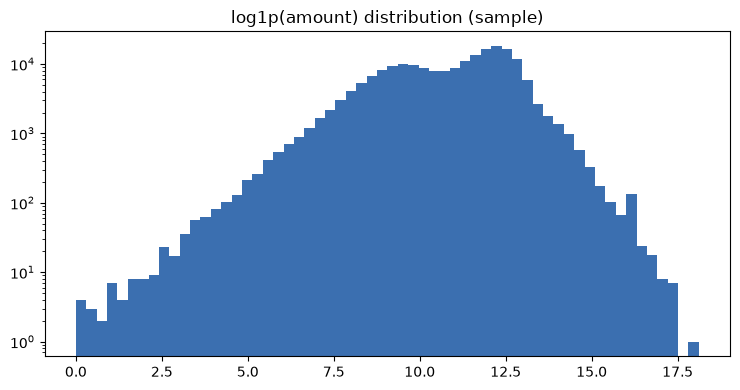

In [46]:
amount_sample = sample_df(["amount"])
if amount_sample is not None:
    import numpy as np

    hist(np.log1p(amount_sample["amount"].to_numpy()), "log1p(amount) distribution (sample)")
else:
    print("Skipped: PaySim CSV unavailable.")

### 📖 Cách đọc — Histogram
- Trục x chia `log1p(amount)` thành các "thùng" (bins); trục y = **số giao dịch** trong mỗi thùng.
- Ta lấy `log1p` (log của 1+amount) vì amount lệch phải cực mạnh — không log thì gần như mọi thứ dồn vào cột đầu, không thấy gì.
- Trục y cũng để **log** để nhìn được cả thùng hiếm.
- Đỉnh cao nhất = mức tiền phổ biến nhất; phần kéo dài sang phải = giao dịch lớn nhưng ít.

<!--read-guide-->

**Categorical frequencies**

,type,rows
0,CASH_OUT,2237500
1,PAYMENT,2151495
2,CASH_IN,1399284
3,TRANSFER,532909
4,DEBIT,41432


,isFraud,rows,pct
0,0,6354407,99.8709
1,1,8213,0.1291


,isFlaggedFraud,rows
0,0,6362604
1,1,16


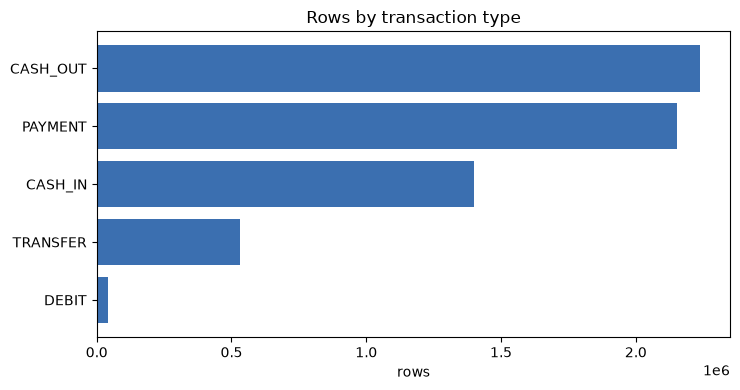

In [47]:
if connection is not None:
    display(Markdown("**Categorical frequencies**"))
    types = q("SELECT type, count(*) AS rows FROM paysim GROUP BY type ORDER BY rows DESC")
    display(types)
    display(
        q(
            "SELECT isFraud, count(*) AS rows, "
            "round(100.0 * count(*) / sum(count(*)) OVER (), 4) AS pct "
            "FROM paysim GROUP BY isFraud ORDER BY isFraud"
        )
    )
    display(
        q(
            "SELECT isFlaggedFraud, count(*) AS rows FROM paysim "
            "GROUP BY isFlaggedFraud ORDER BY isFlaggedFraud"
        )
    )
    barh(types["type"].tolist(), types["rows"].tolist(), "Rows by transaction type", "rows")
else:
    print("Skipped: PaySim CSV unavailable.")

### 📖 Cách đọc
- Bảng `type`: số dòng mỗi loại giao dịch.
- Bảng `isFraud`: cột `pct` = **% gian lận**. Bạn sẽ thấy fraud chỉ ~0.1% → **mất cân bằng cực đoan**. Vì thế "accuracy" vô nghĩa (đoán "không fraud" hết đã đúng ~99.9%); phải dùng PR-AUC / recall.
- `isFlaggedFraud`: cờ theo luật của PaySim — gắn rất ít, **không** phải nhãn thật.

<!--read-guide-->

## Step 4 · Bivariate & multivariate analysis
Relationships between variables: the correlation heatmaps you asked for (Pearson + Spearman), amount vs type/fraud, fraud over time, and the balance-leakage demonstration.

### 📖 Cách đọc một Correlation Heatmap (đọc kỹ phần này)
Heatmap tương quan là **bảng vuông**: hàng và cột đều là các biến số; mỗi ô là **hệ số tương quan** giữa 2 biến, chạy từ **−1 đến +1**.

**Ý nghĩa con số / màu:**
- **+1** (đỏ đậm): đi **cùng chiều** hoàn hảo — biến này tăng thì biến kia tăng.
- **0** (màu nhạt): **không** có quan hệ tuyến tính.
- **−1** (xanh đậm): đi **ngược chiều** hoàn hảo — biến này tăng thì biến kia giảm.

**Cách nhìn nhanh:**
1. **Đường chéo luôn = 1** (mỗi biến tương quan hoàn hảo với chính nó) → bỏ qua.
2. Bảng **đối xứng** qua đường chéo → chỉ cần đọc một nửa.
3. Săn các **ô đậm (đỏ/xanh) nằm ngoài đường chéo** = 2 biến liên quan mạnh → có thể **thừa / trùng thông tin** (collinear).
4. Ô càng **nhạt** = 2 biến càng **độc lập**.

**Kỳ vọng với PaySim:** các cột số dư (`oldbalance*`, `newbalance*`) và `amount` sẽ liên quan nhau (đỏ). Quan trọng: **`isFraud` tương quan RẤT YẾU** với hầu hết cột numeric thô — nghĩa là "nhìn một con số đơn lẻ" không phát hiện được fraud; tín hiệu nằm ở *quan hệ theo thời gian giữa các giao dịch*. Đó chính là lý do dự án phải tự xây **12 feature lịch sử PIT** (notebook 07).

<!--read-guide-->

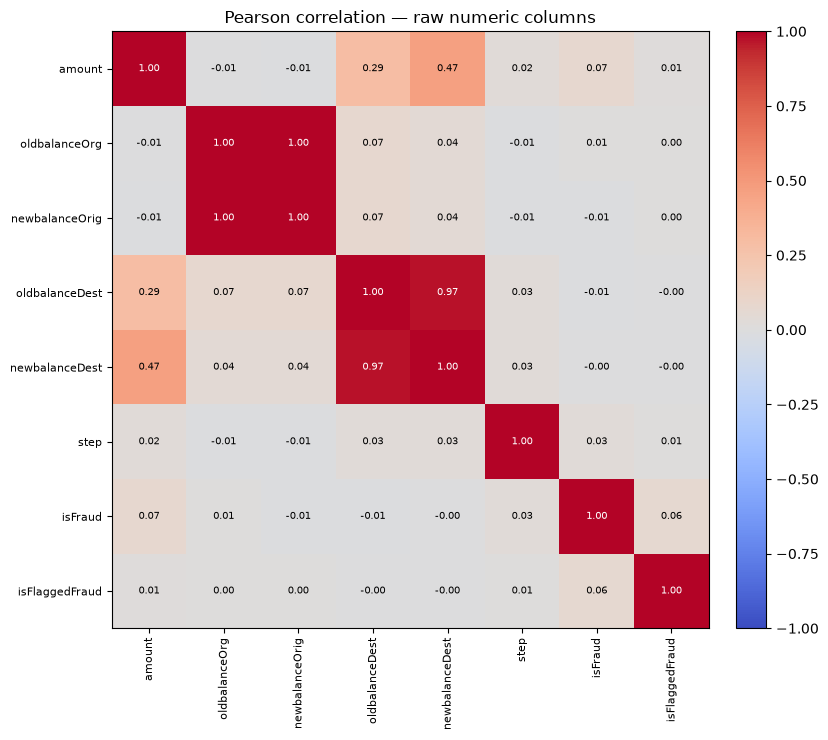

In [48]:
corr_sample = sample_df(CORRELATION_COLUMNS)
if corr_sample is not None:
    corr_sample = corr_sample.astype("float64")
    heatmap(corr_sample.corr(method="pearson"), "Pearson correlation — raw numeric columns")
else:
    print("Skipped: PaySim CSV unavailable.")

### 📖 Chú ý trên heatmap Pearson
Pearson đo quan hệ **tuyến tính (đường thẳng)**. Nó nhạy với outlier và đuôi dài, nên với amount/balance (lệch nặng) Pearson có thể **thấp giả** dù 2 biến vẫn liên quan. Vì vậy ta so tiếp với Spearman ở dưới.

<!--read-guide-->

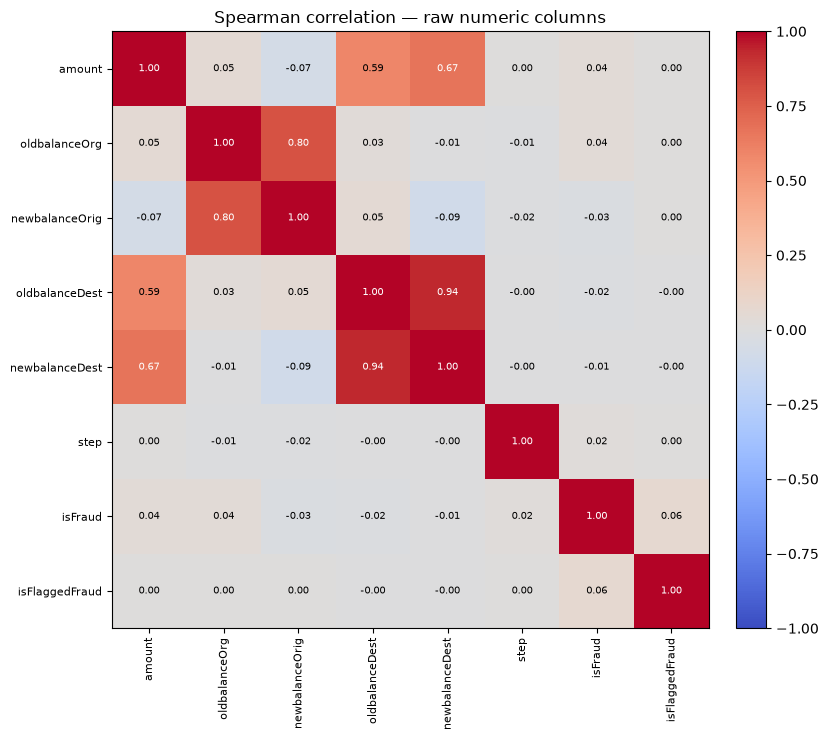

In [49]:
if corr_sample is not None:
    heatmap(corr_sample.corr(method="spearman"), "Spearman correlation — raw numeric columns")
else:
    print("Skipped: PaySim CSV unavailable.")

### 📖 Pearson vs Spearman — khác nhau chỗ nào
- **Pearson**: quan hệ tuyến tính; đường quan hệ phải gần thẳng mới cho số cao.
- **Spearman**: quan hệ **thứ hạng / đơn điệu** — chỉ cần "cứ tăng là tăng" (dù cong) là cho số cao; **bền với đuôi dài**.
- **Mẹo đọc:** nếu ở một cặp mà **Spearman cao hơn hẳn Pearson** → quan hệ có thật nhưng **phi tuyến (cong)**. Model dạng cây (RandomForest / LightGBM) bắt được loại này, model tuyến tính (Logistic) thì bỏ lỡ — một lý do ta sẽ so cả 2 họ model ở bước ladder.

<!--read-guide-->

**Fraud rate by type — fraud lives only in TRANSFER and CASH_OUT**

,type,rows,fraud_rows,fraud_pct
0,TRANSFER,532909,4097.0,0.7688
1,CASH_OUT,2237500,4116.0,0.1840
2,PAYMENT,2151495,0.0,0.0000
3,DEBIT,41432,0.0,0.0000
4,CASH_IN,1399284,0.0,0.0000


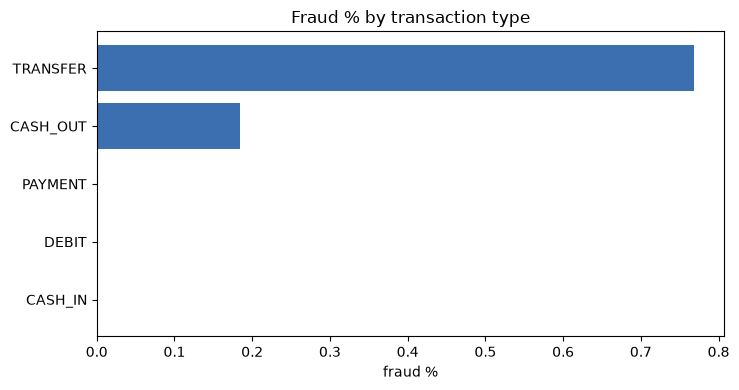

In [50]:
if connection is not None:
    display(Markdown("**Fraud rate by type — fraud lives only in TRANSFER and CASH_OUT**"))
    fraud_by_type = q(
        "SELECT type, count(*) AS rows, sum(isFraud) AS fraud_rows, "
        "round(100.0 * avg(isFraud), 4) AS fraud_pct "
        "FROM paysim GROUP BY type ORDER BY fraud_pct DESC"
    )
    display(fraud_by_type)
    barh(
        fraud_by_type["type"].tolist(),
        fraud_by_type["fraud_pct"].tolist(),
        "Fraud % by transaction type",
        "fraud %",
    )
else:
    print("Skipped: PaySim CSV unavailable.")

### 📖 Cách đọc
`fraud_pct` = % giao dịch gian lận trong mỗi loại. Bạn sẽ thấy fraud **chỉ xuất hiện ở `TRANSFER` và `CASH_OUT`**, các loại khác 0%. Đây là bằng chứng từ dữ liệu cho việc FeatureSpec chỉ giới hạn phạm vi ở 2 loại này.

<!--read-guide-->

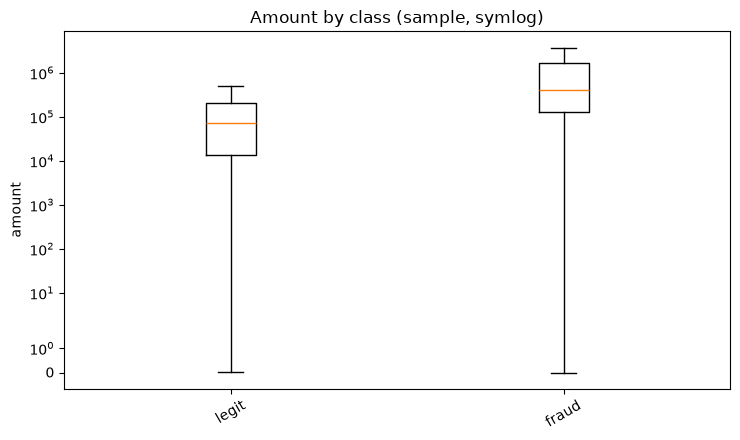

In [51]:
amt_fraud = sample_df(["amount", "isFraud"])
if amt_fraud is not None:
    groups = {
        "legit": amt_fraud.loc[amt_fraud["isFraud"] == 0, "amount"].to_numpy(),
        "fraud": amt_fraud.loc[amt_fraud["isFraud"] == 1, "amount"].to_numpy(),
    }
    boxplot(groups, "Amount by class (sample, symlog)", "amount")
else:
    print("Skipped: PaySim CSV unavailable.")

### 📖 Cách đọc — Boxplot
- **Hộp** = khoảng chứa 50% dữ liệu giữa (phân vị 25% → 75%); **vạch trong hộp** = trung vị.
- **Râu** kéo ra hai đầu = vùng giá trị "bình thường".
- Trục y để **symlog** (log đối xứng) vì amount lệch quá nặng — để tuyến tính thì hộp bị bẹp.
- So 2 hộp **legit vs fraud**: hộp fraud lệch lên cao hơn → giao dịch gian lận có xu hướng số tiền lớn hơn (nhưng đây chỉ là *xu hướng*, chưa đủ để phân loại).

<!--read-guide-->

**Fraud rate over simulation days (step is an hourly ordinal)**

,sim_day,rows,fraud_rows,fraud_pct
0,1,574255,271.0,0.04719
1,2,455238,309.0,0.06788
2,3,1070,310.0,28.97196
3,4,28240,262.0,0.92776
4,5,9789,252.0,2.57432
5,6,441005,228.0,0.05170
6,7,420583,272.0,0.06467
7,8,449637,278.0,0.06183
8,9,417919,255.0,0.06102
9,10,392945,282.0,0.07177


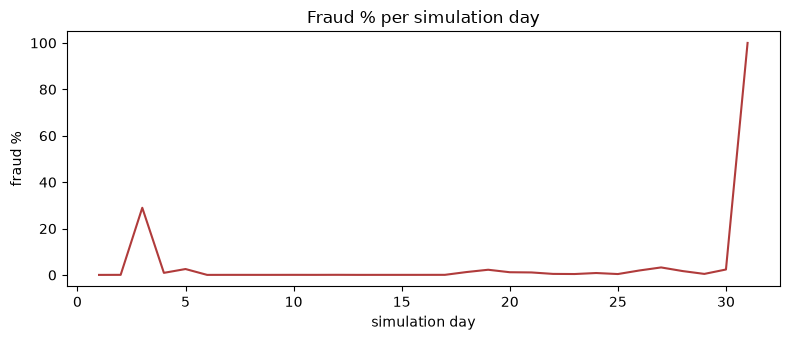

In [52]:
if connection is not None:
    display(Markdown("**Fraud rate over simulation days (step is an hourly ordinal)**"))
    daily = q(
        "SELECT floor((step - 1) / 24)::INTEGER + 1 AS sim_day, "
        "count(*) AS rows, sum(isFraud) AS fraud_rows, "
        "round(100.0 * avg(isFraud), 5) AS fraud_pct "
        "FROM paysim GROUP BY sim_day ORDER BY sim_day"
    )
    display(daily.head(10))
    if HAS_MPL:
        fig, ax = plt.subplots(figsize=(8.0, 3.5))
        ax.plot(daily["sim_day"], daily["fraud_pct"], color="#b03b3b")
        ax.set_xlabel("simulation day")
        ax.set_ylabel("fraud %")
        ax.set_title("Fraud % per simulation day")
        fig.tight_layout()
        plt.show()
else:
    print("Skipped: PaySim CSV unavailable.")

### 📖 Cách đọc
Đường/bảng này cho thấy **% fraud thay đổi theo ngày mô phỏng** (mỗi `step` là 1 giờ, 24 step = 1 ngày). Xem fraud có đều theo thời gian hay dồn vào vài ngày — điều này chi phối cách chia train/validation/test **theo thời gian** (không chia ngẫu nhiên) để tránh nhìn trộm tương lai.

<!--read-guide-->

### Leakage demonstration (why the balance columns are forbidden)
PaySim balance columns encode the transaction *outcome*: for a consistent debit, `oldbalanceOrg - amount ≈ newbalanceOrig`. Fraudulent draining transactions break this identity, so a derived *balance error* separates fraud almost perfectly — which is exactly **post-outcome leakage**. We measure it here to justify excluding these columns; it is **not** a usable feature.

In [53]:
leak = sample_df(
    ["amount", "oldbalanceOrg", "newbalanceOrig", "oldbalanceDest", "newbalanceDest", "isFraud"]
)
if leak is not None:
    leak = leak.astype("float64")
    leak["orig_error"] = leak["oldbalanceOrg"] - leak["amount"] - leak["newbalanceOrig"]
    leak["dest_error"] = leak["oldbalanceDest"] + leak["amount"] - leak["newbalanceDest"]
    summary = leak.groupby("isFraud")[["orig_error", "dest_error"]].mean().round(2)
    display(Markdown("**Mean balance-error by class (leaky signal)**"))
    display(summary)
    try:
        from sklearn.metrics import roc_auc_score

        y = leak["isFraud"].to_numpy()
        for col in ["orig_error", "dest_error"]:
            auc = roc_auc_score(y, leak[col].to_numpy())
            print(f"single-feature AUC {col}: {auc:.4f}  (FORBIDDEN — leakage)")
    except ImportError:
        print("scikit-learn unavailable; skipped leakage AUC.")
else:
    print("Skipped: PaySim CSV unavailable.")

**Mean balance-error by class (leaky signal)**

,orig_error,dest_error
isFraud,,
0.0,-201090.79,54881.92
1.0,-11752.65,695610.02


single-feature AUC orig_error: 0.8871  (FORBIDDEN — leakage)
single-feature AUC dest_error: 0.5789  (FORBIDDEN — leakage)


### 📖 Cách đọc — phần Leakage (quan trọng về khái niệm)
- `orig_error` / `dest_error` = **sai lệch số dư**: giao dịch "sạch" thì ≈ 0. Bảng mean theo class — nếu **fraud lệch khỏi 0 rõ rệt** còn **legit ≈ 0** thì cột này gần như "chỉ điểm" fraud.
- **AUC đơn-feature**: đo một cột đơn tách fraud tốt tới đâu. **0.5 = vô dụng (đoán mò)**, **1.0 = tách hoàn hảo**. Một cột đơn cho **AUC ≈ 0.9+** là dấu hiệu **leakage** — nó đã "biết" kết cục *sau* giao dịch. Vì thế 4 cột số dư bị **cấm** làm feature, dù nhìn thì rất "mạnh".

<!--read-guide-->

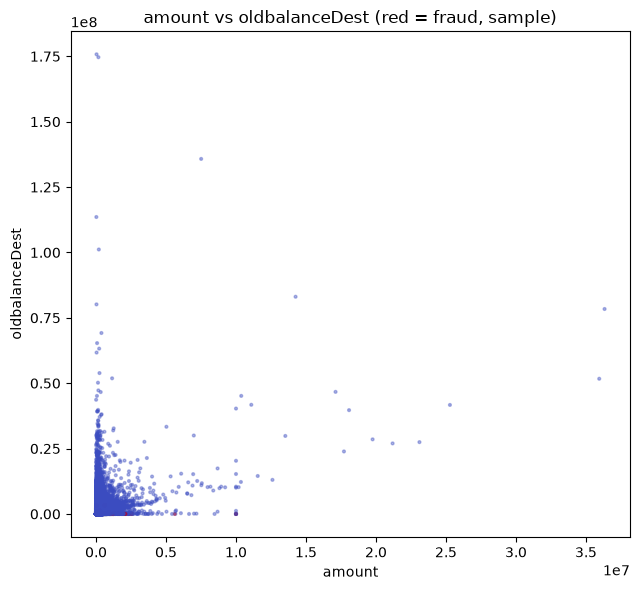

In [54]:
scatter_sample = sample_df(["amount", "oldbalanceDest", "isFraud"], rows=40_000)
if scatter_sample is not None:
    scatter(
        scatter_sample["amount"].to_numpy(),
        scatter_sample["oldbalanceDest"].to_numpy(),
        scatter_sample["isFraud"].to_numpy(),
        "amount vs oldbalanceDest (red = fraud, sample)",
        "amount",
        "oldbalanceDest",
    )
else:
    print("Skipped: PaySim CSV unavailable.")

### 📖 Cách đọc — Scatter
Mỗi chấm là một giao dịch: trục x = `amount`, trục y = `oldbalanceDest` (số dư người nhận trước giao dịch), **đỏ = fraud, xanh = hợp lệ**. Xem các chấm đỏ có tụ thành vùng riêng không (ví dụ dọc đường `oldbalanceDest = 0`). Đỏ tách khỏi xanh rõ = có cấu trúc; nhưng nhớ trục dùng cột balance (leakage) nên chỉ để *hiểu dữ liệu*, không phải để làm feature.

<!--read-guide-->

## Step 5 · Insights & feature-engineering ideas

**What the raw data says**
- **Extreme imbalance** — fraud is a tiny fraction of rows; accuracy is meaningless, PR-AUC / recall@fixed-FPR is the right lens.
- **Fraud is scoped** — it occurs only in `TRANSFER` and `CASH_OUT`. This is *why* the frozen FeatureSpec scopes to those two types.
- **Amount is heavy-tailed** — hence rank (Spearman) reads and log transforms beat raw Pearson.
- **Balance columns leak** — the balance-error identity separates fraud almost perfectly because it encodes the outcome. Confirmed forbidden.

**Feature-engineering directions**
- ✅ *PIT-safe (already built):* recipient/entity **history** aggregates computed strictly before the decision cutoff — the 12 `paysim-fraud-recipient-v2` features. Notebook 07 profiles their correlation/redundancy.
- ❌ *Forbidden:* any balance-delta / balance-error feature, `isFlaggedFraud`, or anything derived from `isFraud`.
- 🔎 *Candidate PIT-safe ideas (contract bump, out of scope this week):* per-entity velocity, distinct-counterparty counts, time-since-last-event — all computable point-in-time.

This raw EDA justifies the frozen contract's scope and forbidden-input list from the data itself, and hands the modeling work (notebook 07 + the Day-2/3 ladder) a clean starting point.

In [1]:
from pit_fintech.config import get_settings

print(get_settings().mlflow_tracking_uri)

http://localhost:5000
